In [136]:
import kwant
from kwant.digest import uniform    # a (deterministic) pseudorandom number generator

import numpy as np
import matplotlib.pyplot as plt
from types import SimpleNamespace

import cmath

from qutip import *

In [137]:
def smooth_box_x(R, Nx):
    xL = 1.*Nx/10.
    xR = 9.*(Nx-1)/10.
    sigmax = 2.
    Pi = ( 1./( np.exp( -(R[:,0] - xL)/sigmax ) + 1. ) * 1./( np.exp( (R[:,0] - xR)/sigmax ) + 1. ) )/1.
    return Pi



def v_img(d, zrange, N):
    arr_V = []
    arr_z = np.linspace(-zrange, zrange, N)
    for z in arr_z:
        V = 0
        nf = 15000
        n_Z = np.linspace( -nf, nf, 2*nf+1)
        for n in n_Z:
            if n != 0:
                V += ( 1./(2*np.abs(n)) - 1./(2.*np.abs(n+z/d + .000000000)) )
        if z < 0:
            arr_V.append(V)
        else:
            arr_V.append(V)
    return arr_z, np.asarray(arr_V)

def v_img_singleside(W, N, min_l):
    arr_z = np.linspace(min_l, W+min_l, N)
    arr_V = - 1./(2*np.abs( 2*(arr_z)/min_l + .00000 ))
    return arr_z, arr_V  



In [138]:
def corr_dis(L, W, a, xic):
    Nx = int(L/a)
    Ny = int(W/a)
    Vxy = np.random.normal(0, 1., size=(Ny, Nx))/(a) + 1j*0.0
    
    kkVxy = np.fft.fft2(Vxy)
    kx = 2*np.pi * np.fft.fftfreq(kkVxy.shape[1],d=a)
    ky = 2*np.pi * np.fft.fftfreq(kkVxy.shape[0],d=a)
    kx, ky = np.meshgrid(kx,ky)
    
    kVxy = np.multiply(kkVxy, np.exp( - .125 * (xic)**2. * (kx**2.+ky**2.)  ) ) * (xic)/np.sqrt(2.)
    
    #xlong = W/4.
    #xavg = (xic + xlong)/2.
    #kVxy = np.multiply(kkVxy, np.exp( - .125**3. * xic**4. * (kx**4.+ky**4.)  ) ) * (xavg/2.)/np.sqrt(2.)
    #kVxy += np.multiply(kkVxy, np.exp( - .125 * (xlong)**2. * (kx**2.+ky**2.)  ) ) * (xavg/2.)/np.sqrt(2.)
    
    Vxy = np.fft.ifft2(kVxy)
    Vxy = Vxy - np.sum(Vxy)/(1.*Nx*Ny)

    return Vxy

(1.9626105055051506+0j)


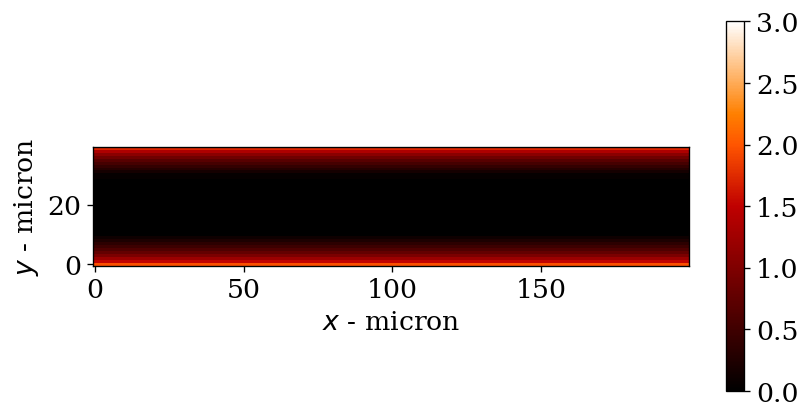

In [139]:

def tan_confinement(L, W, dr, Wedge, A):
    Vxy = np.zeros(shape=(W, L), dtype=np.complex_)
    Nedge = int(Wedge/dr)
    xvec = np.linspace(0, L-1, int(L) )
    yvec = np.linspace(0, W-1, int(W) )    
    
    
    minRy = np.amin(yvec)
    maxRy = np.amax(yvec)
    for ny in range(W):
        for nx in range(L):
            if yvec[ny] <= (Wedge + minRy):
                Vxy[ny][nx] = (np.tan(A * np.pi/2.*( yvec[ny] - (Wedge + minRy) )/Wedge  ) )**2.
            elif yvec[ny] >= (maxRy-(Wedge)):
                Vxy[ny][nx] = (np.tan(A * np.pi/2.*( yvec[ny] - (maxRy-(Wedge) + dr/2.  ) )/Wedge  ) )**2.
    
    return np.sqrt(Vxy)

L=200
W=40
Vconf = tan_confinement(L, W, 1., W/4, .7)

xvec = np.linspace(0, L-1, int(L) )
yvec = np.linspace(0, W-1, int(W) )
X, Y = np.meshgrid(xvec, yvec)

fig_conf, ax_conf = plt.subplots(dpi=120, figsize=(8, 4))

vmin = 0.
vmax = 3.000
conf_plot = ax_conf.pcolormesh(X*1, Y*1, (Vconf.real), cmap='gist_heat', alpha=1, vmin=vmin, vmax=vmax)

fig_conf.colorbar(conf_plot)

ax_conf.set_xlabel(r'$x$ - micron')
ax_conf.set_ylabel(r'$y$ - micron')
ax_conf.set_aspect('equal')
print(np.amax(Vconf) )

In [140]:
lat = kwant.lattice.square(a=1, norbs=1)

t = 1   # hopping rate for kwant
W = 80  # spatial width of the system ( Nx )
L = 40  # spatial length of the system ( Ny )

# Energy-Length-Magnetic scale (arbitrary) just to have a dimensional reference for the parameters
#a=0.6 nm in GaAs
BandW0 = 40*1   #total bandwidth in meV
l0 = np.sqrt(568/BandW0*8.) * 10**(-3.) # sqrt( \hbar^2/(2m*)/(\hbar J)) here I took \hbar^2/(2m*) = 568 nm^2 meV (GaAs) and \hbar J = BW/8 in micron!
B0 = 4.14*10**3. / (l0 * 10**3.)**2. #in T, as 2\pi \hbar/e 1/a^2

# Adimensional magnetic flux
alpha = 1./40.
lB = 1./np.sqrt(2*np.pi*alpha)
omB0 = 4*np.pi*alpha * 2    #factor of '2' comes from kwant's hopping rate which is 2t=2 ... there is a little mess around for this...

# Correlation length and definition of disorder-potential array
xic = 10./(l0*1e3)
Vdis = corr_dis(int(L), int(W), 1, xic)

#edge-plate distance and 'd'-distance between the plates
plate_distance = 40 * 1e-3/l0 #edge-plate distance
d = W + 2*plate_distance #'d'-distance between the plates

# relative permittivity
epsilon_r = 13.


arr_z, Vimg = v_img_singleside(W, int(W), plate_distance)   # normalized image potential single plate (arr_z I don't know what is, it is useless)
#arr_z, Vimg = v_img(d, W/2., int(W))                       # normalized image potential double plates (arr_z I don't know what is, it is useless)

#IMG = 40*(1.44/(BandW0/8))/(epsilon_r*l0*d) #double-plate image charge energy constant in meV 
IMG = (1.44/(BandW0/8))/(epsilon_r*l0*plate_distance) #single-plate image charge energy constant in meV 
Vimg = Vimg - np.amax(Vimg)                            # shift the max of the potential to 0
sigmaX = 2000   #???
x_off = 8       #???

E = 100./(BandW0/8.) * 0                #eventual electric field amplitude
#VE = np.linspace(-W/2, W/2,W)/d + .5
VE = np.linspace(0, W,W)/d              #electric field potential shape (linear)
#VE = VE - np.amin(VE)*(1/4)*E/np.abs(E)

dis = .06/(BandW0/8.)                   # disorder amplitude (in meV)

E_offset_E = np.amin(E*VE)      #???
E_offset_IMG = np.amin(IMG*Vimg)#???

# Definitions for Kwant
def onsite(site, params):
    xi, yi = site.pos
    
    om0 = + 4 * t
    #omE = params.E*(yi - W/1 )/d
    omE = params.E*params.VE[int(yi)]
    omRan = params.dis*params.V[int(yi)][int(xi)]
    #omImg = params.IMG * Vimg[int(yi)] * ( 1./( np.exp( -(xi-x_off)/sigmaX ) + 1. ) * 1./( np.exp( (xi-(L-1-x_off))/sigmaX ) + 1. ) )
    omImg = params.IMG * Vimg[int(yi)] * np.exp( -(xi-L/2)**2/(2*sigmaX**2) )
    
    return  om0 + omE + omRan + omImg

def hopping(site_i, site_j, params):
    xi, yi = site_i.pos
    xj, yj = site_j.pos
    return - t*np.exp(-1j * 2*np.pi * params.alpha * (xi - xj) * (yi + yj))

def onsite_lead(site, params):
    xi, yi = site.pos
    omL = params.E*params.VE[int(yi)]
    return  4 * t + (params.E_offset_es + params.E_offset_dis)*0 + omL*0

def hopping_lead(site_i, site_j, params):
    xi, yi = site_i.pos
    xj, yj = site_j.pos
    return - t #*np.exp(-1j * 2*np.pi * params.alpha * (xi - xj) * (yi + yj))

sys = kwant.Builder()
sys[(lat(x, y) for x in range(L) for y in range(W))] = onsite
sys[lat.neighbors()] = hopping


sym_left_lead = kwant.TranslationalSymmetry((-1, 0))
left_lead = kwant.Builder(sym_left_lead)
#left_lead[(lat(0, y) for y in range(W))] = 4 * t + E_offset_es - dis/2
left_lead[(lat(0, y) for y in range(W))] = onsite_lead
left_lead[lat.neighbors()] = hopping_lead
sys.attach_lead(left_lead)
sys.attach_lead(left_lead.reversed())


sys = sys.finalized()

print(l0*10**3., xic*l0*10**3, lB*l0*10**3, B0*alpha, omB0*BandW0/8., 18/(BandW0/8.))


10.658330075579382 9.999999999999998 26.892379244119933 0.9110915492957746 3.141592653589793 3.6


In [141]:
print(E_offset_E+E_offset_IMG, IMG/2)

-0.1322571361215965 0.2769230769230769


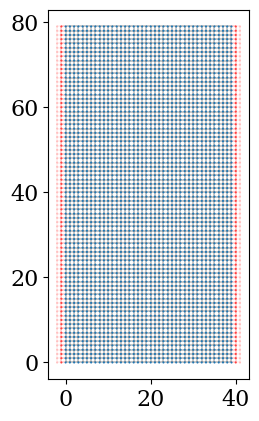

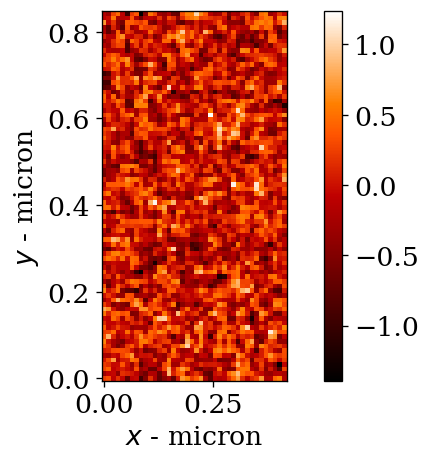

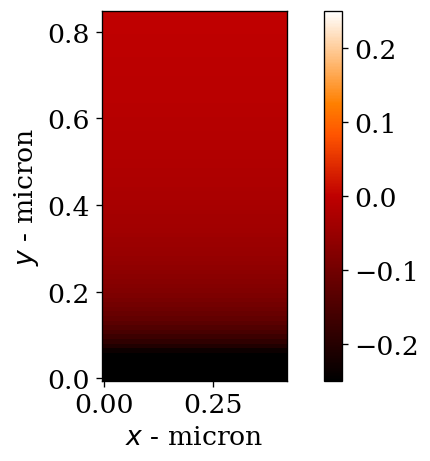

In [142]:
#plot some structural kwant stuff

kwant.plot(sys);

xvec = np.linspace(0, L-1, int(L) )
yvec = np.linspace(0, W-1, int(W) )
X, Y = np.meshgrid(xvec, yvec)

fig_W, ax_W = plt.subplots(dpi=120, figsize=(8, 4))
vmin = 0.
vmax = 1.000
Wmap_plot = ax_W.pcolormesh(X*l0, Y*l0, (Vdis.real), cmap='gist_heat', alpha=1)  #, vmin=vmin, vmax=vmax)
fig_W.colorbar(Wmap_plot)
ax_W.set_xlabel(r'$x$ - micron')
ax_W.set_ylabel(r'$y$ - micron')
ax_W.set_aspect('equal')

#arr_omImg = np.tile(Vimg, (int(L), 1)).T * ( 1./( np.exp( -(X-x_off)/sigmaX ) + 1. ) * 1./( np.exp( (X-(L-1-x_off))/sigmaX ) + 1. ) )/1.
arr_omImg = np.tile(Vimg, (int(L), 1)).T  * np.exp( -(X-L/2)**2/(2*sigmaX**2) )
arr_VE = np.tile(VE, (int(L), 1)).T


fig_Img, ax_Img = plt.subplots(dpi=120, figsize=(8, 4))

vmin = -.25
vmax = .25
Img_plot = ax_Img.pcolormesh(X*l0, Y*l0, ((IMG*arr_omImg+arr_VE*E)*BandW0/8), cmap='gist_heat', alpha=1, vmin=vmin, vmax=vmax)

fig_Img.colorbar(Img_plot)

ax_Img.set_xlabel(r'$x$ - micron')
ax_Img.set_ylabel(r'$y$ - micron')
ax_Img.set_aspect('equal')



/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_18789/1468399739.py:18: KwantDeprecationWarning:

The 'args' parameter has been deprecated since version 1.4 -- Instead, provide named parameters as a dictionary via 'params'.

/opt/anaconda3/lib/python3.12/site-packages/kwant/solvers/common.py:151: KwantDeprecationWarning:

The 'args' parameter has been deprecated since version 1.4 -- Instead, provide named parameters as a dictionary via 'params'.

/opt/anaconda3/lib/python3.12/site-packages/kwant/solvers/common.py:204: KwantDeprecationWarning:

The 'args' parameter has been deprecated since version 1.4 -- Instead, provide named parameters as a dictionary via 'params'.

/opt/anaconda3/lib/python3.12/site-packages/kwant/system.py:330: KwantDeprecationWarning:

The 'args' parameter has been deprecated since version 1.4 -- Instead, provide named parameters as a dictionary via 'params'.

/opt/anaconda3/lib/python3.12/site-packages/kwant/system.py:291: KwantDeprecationWarning:

The

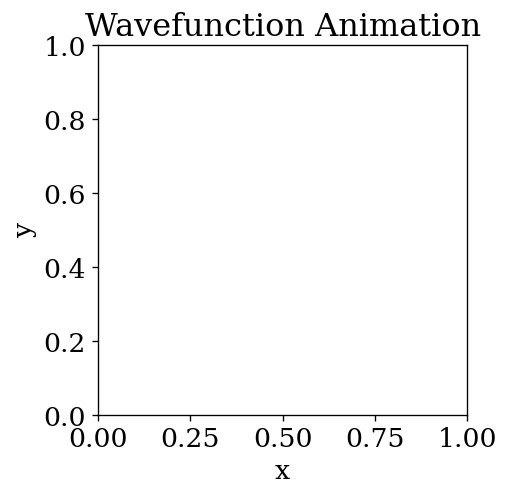

In [143]:
# compute and plot some scattering states

ei = 2 /(BandW0/8.)   #initial energy in meV (highest) for the conductance sweep in fermi energy
ef = 0 /(BandW0/8.)   #final energy (lowest) for the conductance sweep in fermi energy
Ne = 100        #number of points for the conductance sweep
energies = np.linspace( ei, ef, Ne)  # Define a range of fermi energies to scan


#E = .0 /(BandW0/8.)
#dis = 1./(BandW0/8.)


#plate_distance = 40 * 1e-3/l0
#d = W + 2*plate_distance
#IMG = (1.44/(BandW0/8))/(epsilon_r*l0*d)

wavefunctions = []
for energy in energies:    
    params = SimpleNamespace(alpha=alpha, E=E, dis=dis, IMG=IMG, V=Vdis, Vimg=Vimg, VE=VE, E_offset_es=E_offset_E, E_offset_dis=dis*np.amin(Vdis) )
    wfs = kwant.wave_function(sys, energy=energy, args=[params])
    scattering_wf = wfs(0)
    wavefunctions.append( scattering_wf )
    
from matplotlib.animation import FuncAnimation
from IPython.display import HTML    

fig, ax = plt.subplots(dpi=120, figsize=(8, 4))

def init():
    ax.clear()
    ax.set_title('Wavefunction Animation')
    ax.set_xlabel('x')
    ax.set_ylabel('y')

def update(frame):
    ax.clear()
    init()
    psi = wavefunctions[frame]
    kwant.plotter.map(sys, (np.sum(abs(psi)**2, axis=0)), ax=ax, show=False)

ani = FuncAnimation(fig, update, frames=len(energies), init_func=init, repeat=False)

HTML(ani.to_jshtml())

In [144]:
#core routine: compute the conductance G

from joblib import Parallel, delayed


#plate_distance = 2 * 1e-3/l0
#d = W + 2*plate_distance
#IMG = (1.44/(BandW0/8))/(l0*d)

#E = 0.0 /(BandW0/8.)    #in meV
#dis = 1./(BandW0/8.)
#IMG = (1.44/(BandW0/8))/(epsilon_r*l0*plate_distance)

ei = 12 /(BandW0/8.)   #initial energy in meV (highest) for the conductance sweep in fermi energy
ef = 0 /(BandW0/8.)   #final energy (lowest) for the conductance sweep in fermi energy
Ne = 400        #number of points for the conductance sweep
energies = np.linspace( ei, ef, Ne)  # Define a range of fermi energies to scan

def G_conductance( E, dis, IMG, L, W, alpha, Vdis, Vimg, energies  ):

    G0 = []
    GIMG = []

    G0xx = []
    GIMGxx = []

    for energy in energies:
        #print(energy)
        g0 = 0
        gimg = 0
        g0xx =  0
        gimgxx = 0
        
        Vdis = corr_dis(int(L), int(W), 1, xic)
            
        params =SimpleNamespace(alpha=alpha, E=0, dis=dis, IMG=0, V=Vdis, Vimg=Vimg, VE=VE, E_offset_es=0, E_offset_dis=np.amin(dis*Vdis) )
        smat = kwant.smatrix(sys, energy=energy, args=[params])
        
        params_IMG = SimpleNamespace(alpha=alpha, E=E, dis=dis, IMG=IMG, V=Vdis, Vimg=Vimg, VE=VE, E_offset_es=E_offset_E+E_offset_IMG, E_offset_dis=np.amin(dis*Vdis) )
        smat_IMG = kwant.smatrix(sys, energy=energy, args=[params_IMG])
        
        g0 += np.abs(smat.transmission(0, 1))
        gimg += np.abs(smat_IMG.transmission(0, 1))
        g0xx +=  np.abs(smat.transmission(0, 0))
        gimgxx += np.abs(smat_IMG.transmission(0, 0))
            
        G0.append( g0 )   
        GIMG.append( gimg )
        
        G0xx.append( g0xx )   
        GIMGxx.append( gimgxx )
        

    G0 = np.asarray(G0)
    GIMG = np.asarray(GIMG)
    G0xx = np.asarray(G0xx)
    GIMGxx = np.asarray(GIMGxx)


    return G0, G0xx, GIMG, GIMGxx


# Initialize variables
iter_dis = 20
G0 = np.zeros(len(energies))
G0xx = np.zeros(len(energies))
GIMG = np.zeros(len(energies))
GIMGxx = np.zeros(len(energies))

# Define a function to compute conductance for a single iteration
def compute_conductance(ndis):
    return G_conductance(E, dis, IMG, L, W, alpha, Vdis, Vimg, energies)

# Use joblib to parallelize the loop
results = Parallel(n_jobs=5)(
    delayed(compute_conductance)(ndis) for ndis in range(iter_dis)
)

# Aggregate the results
for sG0, sG0xx, sGIMG, sGIMGxx in results:
    G0 += sG0 / iter_dis
    G0xx += sG0xx / iter_dis
    GIMG += sGIMG / iter_dis
    GIMGxx += sGIMGxx / iter_dis

/opt/anaconda3/lib/python3.12/site-packages/kwant/solvers/default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "
/opt/anaconda3/lib/python3.12/site-packages/kwant/solvers/default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "
/opt/anaconda3/lib/python3.12/site-packages/kwant/solvers/default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "
/opt/anaconda3/lib/python3.12/site-packages/kwant/solvers/default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "
/opt

In [145]:
#????
Delta_e = np.abs(ei - ef)
deltaG = np.sum( np.abs( GIMG - G0 ) )/Ne
print(deltaG)

0.10561521818287449


In [146]:
minV = IMG*np.amin(Vimg)

In [147]:
# introduce finite temperature
def fermi_f(T, E, dE):
    if np.abs(E/T) < 100.:
        if dE/T < 1.:
            dF = - np.exp(E/T) / (np.exp(E/T) + 1.)**2. / T * dE
        else:
            dF = 1.
    else:
        dF = 0
    return dF

def finite_temp(T, N, G, energies):
    W = []
    E = []
    half_N = N // 2
    num_points = len(G)
    for n in range(num_points):
        weighted_sum = 0
        norm_factor = 0
        for i in range(-half_N, half_N + 1):
            index = n + i
            if 0 <= index < num_points:
                weight = fermi_f(T, energies[n] - energies[index], energies[n] - energies[n-1] if n > 0 else 1)
                weighted_sum += G[index] * weight
                norm_factor += weight
        W.append(weighted_sum / norm_factor if norm_factor != 0 else 0)
        E.append(energies[n])
    return np.array(W), np.array(E)


mu_bohr = 0.86 # Bohr magneton meV x T e\hbar^2/2m

G0T, energiesT =  G0, energies
G0xxT, energiesT = G0xx, energies

GIMGT, energiesTIMG = GIMG, energies
GIMGxxT, energiesTIMG = GIMGxx, energies

T0 = .001/(BandW0/8.)   # temperature in meV
N0 = 120                # number of energy to average
TIMG = T0
NIMG = N0

G0T, energiesT = finite_temp(T0, N0, G0, energies)
G0xxT, energiesT = finite_temp(T0, N0, G0xx, energies)

GIMGT, energiesTIMG = finite_temp(TIMG, NIMG, GIMG, energies)
GIMGxxT, energiesTIMG = finite_temp(TIMG, NIMG, GIMGxx, energies)

det0T = G0T**2. + G0xxT**2.
rhoxy0T = np.divide(np.abs(G0T), det0T)
rhoxx0T = np.divide(np.abs(G0xxT), det0T)

detIMGT = GIMGT**2 + GIMGxxT**2
rhoxyIMGT = np.divide(np.abs(GIMGT), detIMGT)
rhoxxIMGT = np.divide(np.abs(GIMGxxT), detIMGT)


dG0T_dE = np.gradient(G0T, energiesT)
dGIMGT_dE = np.gradient(GIMGT, energiesT)



In [148]:
print(T0/(1.*IMG * lB*l0*(1)**.5/(BandW0/8)))

0.06714004510963245


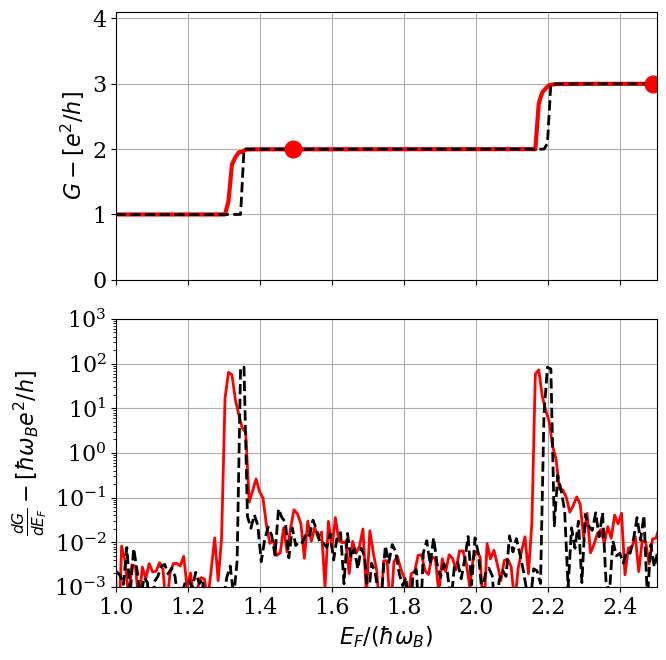

In [149]:
#print plateous

# Font configuration
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
# Apply the font globally
plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']

# Create the figure and subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8))
# First subplot
"""ax1.plot(energies / omB0, 1 * np.ones(energies.size), linestyle=':', color='red')
for i in range(2, 7):
    ax1.plot(energies / omB0, i * np.ones(energies.size), linestyle=':', color='red')"""
ax1.plot( (energiesT) / omB0, GIMGT, color='red', linewidth=3)
ax1.plot( (energiesT +minV/4) / omB0, G0T, color='black', linewidth=2, linestyle='--')


Et = 1.*IMG * lB*l0*(1)**.5 
ax1.plot( ( Et + .5*omB0+minV/4 + dis)/ omB0, 1, color='red', marker='o', markersize=12)
ax1.plot( (Et + 1.5*omB0+minV/4+ dis)/ omB0, 2, color='red', marker='o', markersize=12)
ax1.plot( (Et + 2.5*omB0+minV/4+ dis)/ omB0, 3, color='red', marker='o', markersize=12)
ax1.plot( (Et + 3.5*omB0+minV/4+ dis)/ omB0, 4, color='red', marker='o', markersize=12)
ax1.plot( (Et + 4.5*omB0+minV/4+ dis)/ omB0, 5, color='red', marker='o', markersize=12)

ax1.set_ylabel(r"$G - [e^2/h]$", fontdict=font)
#ax1.set_xlabel(r"$E_F/(\hbar\omega_B)$", fontdict=font)
ax1.set_xlim((np.amin(energiesT)/ omB0,np.amax(energiesT)* BandW0 / 8.))

ax1.set_ylim((.0, 4.1))
ax1.set_xlim((1, 2.5))

max0 = np.amax(np.abs(dG0T_dE))*0+1
maximg = np.amax(np.abs(dGIMGT_dE))*0+1
ax2.plot( (energiesT) / omB0, np.abs(dGIMGT_dE)/maximg, color='red', linewidth=2, linestyle='-')
ax2.plot( (energiesT+minV/4) / omB0, np.abs(dG0T_dE)/max0, color='black', linewidth=2, linestyle='--')

ax2.set_ylabel(r"$\frac{dG}{dE_F} - [\hbar \omega_Be^2/h]$", fontdict=font)
ax2.set_xlabel(r"$E_F/(\hbar\omega_B)$", fontdict=font)


#ax2.set_ylim((0, 1.))
#ax2.set_xlim((0, 3))

ax2.set_ylim((1e-3, 1e3))  # Adjust the lower limit to avoid log(0) issues
ax2.set_xlim((1, 2.5))

ax2.set_yscale('log')  # Set log scale on y-axis


ax1.grid()
ax2.grid()
ax1.set_xticklabels([])

plt.tight_layout()
plt.gcf().set_size_inches(170 / 25.4, 170 / 25.4)
#plt.savefig('GR_Nx%d_Ny%d_BW%.2f_dis%.2f_xic%.2f_IMG%.2f_alpha%.2f_W%dL%d_pltdist%d_T%.3f.svg' % (L, W, BandW0, dis, xic, IMG, alpha, W, L, plate_distance, T0))
#plt.savefig('GR_Nx%d_Ny%d_BW%.2f_dis%.2f_xic%.2f_IMG%.2f_alpha%.2f_W%dL%d_pltdist%d_T%.3f.pdf' % (L, W, BandW0, dis, xic, IMG, alpha, W, L, plate_distance, T0))

plt.show()

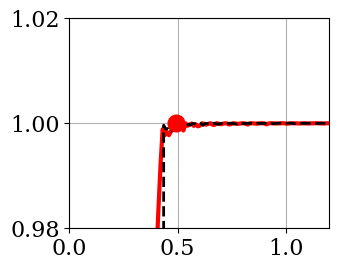

In [150]:
# Font configuration
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
# Apply the font globally
plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']

# Create the figure and subplots
fig, (ax1) = plt.subplots(1, 1, figsize=(8, 8))
# First subplot

ax1.plot( (energiesT) / omB0, GIMGT, color='red', linewidth=3)
ax1.plot( (energiesT +minV/4) / omB0, G0T, color='black', linewidth=2, linestyle='--')

#ax1.set_ylabel(r"$G - [e^2/h]$", fontdict=font)
#ax1.set_xlabel(r"$E_F/(\hbar\omega_B)$", fontdict=font)
ax1.set_xlim((np.amin(energiesT)/ omB0,np.amax(energiesT)* BandW0 / 8.))

ax1.set_ylim((.98, 1.02))
ax1.set_xlim((0, 1.2))

ax1.plot( (1.*IMG * lB*l0*(1)**.5 + .5*omB0+minV/4 + dis)/ omB0, 1, color='red', marker='o', markersize=12)


ax1.grid()


plt.tight_layout()
plt.gcf().set_size_inches(80 / 25.4, 60 / 25.4)
#plt.savefig('zoomGR_Nx%d_Ny%d_BW%.2f_dis%.2f_xic%.2f_IMG%.2f_alpha%.2f_W%dL%d_pltdist%d_T%.3f.svg' % (L, W, BandW0, dis, xic, IMG, alpha, W, L, plate_distance, T0))
#plt.savefig('zoomGR_Nx%d_Ny%d_BW%.2f_dis%.2f_xic%.2f_IMG%.2f_alpha%.2f_W%dL%d_pltdist%d_T%.3f.pdf' % (L, W, BandW0, dis, xic, IMG, alpha, W, L, plate_distance, T0))

plt.show()

/var/folders/y4/dpq6l9fj2kv9z0prq_6_pyy00000gn/T/ipykernel_18789/3484678707.py:19: RuntimeWarning:

divide by zero encountered in divide



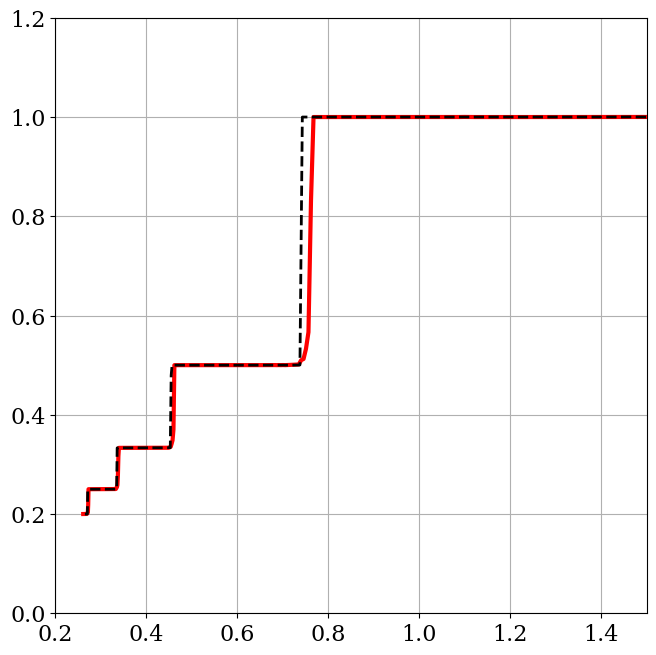

In [151]:
# Font configuration
font = {
    'family': 'serif',
    'color': 'black',
    'weight': 'normal',
    'size': 16,
}
# Apply the font globally
plt.rcParams['font.family'] = font['family']
plt.rcParams['font.size'] = font['size']
plt.rcParams['axes.labelsize'] = font['size']
plt.rcParams['xtick.labelsize'] = font['size']
plt.rcParams['ytick.labelsize'] = font['size']

# Create the figure and subplots
fig, (ax1) = plt.subplots(1, 1, figsize=(8, 8))
# First subplot

ax1.plot( 1/((energiesT) / omB0), 1/GIMGT, color='red', linewidth=3)
ax1.plot( 1/((energiesT +minV/4) / omB0), 1/G0T, color='black', linewidth=2, linestyle='--')

#ax1.set_ylabel(r"$G - [e^2/h]$", fontdict=font)
#ax1.set_xlabel(r"$E_F/(\hbar\omega_B)$", fontdict=font)
ax1.set_xlim((np.amin(energiesT)/ omB0,np.amax(energiesT)* BandW0 / 8.))

ax1.set_ylim((0, 1.2))
ax1.set_xlim((0.2, 1.5))

#ax1.plot( (1.*IMG * lB*l0*(1)**.5 + .5*omB0+minV/4 + dis)/ omB0, 1, color='red', marker='o', markersize=12)


ax1.grid()


plt.tight_layout()
plt.gcf().set_size_inches(170 / 25.4, 170 / 25.4)
#plt.savefig('zoomGR_Nx%d_Ny%d_BW%.2f_dis%.2f_xic%.2f_IMG%.2f_alpha%.2f_W%dL%d_pltdist%d_T%.3f.svg' % (L, W, BandW0, dis, xic, IMG, alpha, W, L, plate_distance, T0))
#plt.savefig('zoomGR_Nx%d_Ny%d_BW%.2f_dis%.2f_xic%.2f_IMG%.2f_alpha%.2f_W%dL%d_pltdist%d_T%.3f.pdf' % (L, W, BandW0, dis, xic, IMG, alpha, W, L, plate_distance, T0))

plt.show()

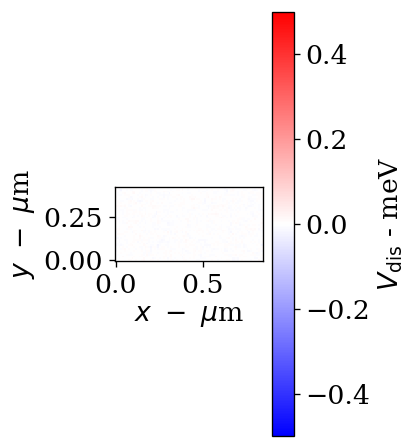

In [152]:
from matplotlib.colors import LinearSegmentedColormap
# Create a custom colormap
cmap = LinearSegmentedColormap.from_list('blue_white_red', ['blue', 'white', 'red'])

# Create vectors and meshgrid
xvec = np.linspace(0, L-1, int(L))
yvec = np.linspace(0, W-1, int(W))
X, Y = np.meshgrid(xvec, yvec)

# Plotting
fig_W, ax_W = plt.subplots(dpi=120, figsize=(4, 4))
font = {'family': 'serif',
        'color': 'black',
        'weight': 'normal',
        'size': 16,
        }
vmin = -.5  # Set the minimum value for colormap
vmax = .5   # Set the maximum value for colormap
Wmap_plot = ax_W.pcolormesh( Y.T*l0, X.T*l0, (Vdis.real*dis).T, cmap=cmap, alpha=1, vmin=vmin, vmax=vmax)
cbar = fig_W.colorbar(Wmap_plot,shrink=0.6)
cbar.set_label(r'$V_{\rm dis}$ - meV', fontdict=font)  # Add label to colorbar

# Axis labels
ax_W.set_xlabel(r'$x ~ - ~ \mu$m', fontdict=font)
ax_W.set_ylabel(r'$y ~ - ~ \mu$m', fontdict=font)
ax_W.set_aspect('equal')

# Additional array calculation
sigmaXX = L / .1
arr_omImg = np.multiply(np.tile(Vimg, (int(L), 1)).T, np.exp(-(X-L/2.+.5)**2. / (2.*(sigmaXX)**2.)))

plt.tight_layout()
plt.gcf().set_size_inches(80 / 25.4, 170 / 25.4)
#plt.savefig("Vdis.svg")
#plt.savefig("Vdis_dis%.3f_xic%.2f.svg" % (dis,xic))
#plt.savefig("Vdis_dis%.3f_xic%.2f.pdf" % (dis,xic))

# Show plot
plt.show()


In [153]:
# save platos in a file

import pandas as pd

nG = 0

# Parameters
params = {
    "t": t,
    "W": W,
    "L": L,
    "BandW0": BandW0,
    "alpha": alpha,
    "xic": xic,
    "plate_distance": plate_distance,
    "epsilon_r": epsilon_r,
    "ei": ei,
    "ef": ef,
    "Ne": Ne,
    "E": E,
    "iter_dis": iter_dis,
}

# Create a DataFrame
data = pd.DataFrame({
    'Energies': energies,
    'G0': G0,
    'GIMG': GIMG
})

# Write parameters and data to a file
filename = 'G_%d.dat' % (nG)
with open(filename, 'w') as f:
    # Write parameters as comments
    for key, value in params.items():
        f.write(f"# {key} = {value}\n")
    # Write the data
    data.to_csv(f, sep=' ', index=False, header=True)